# Video Game Sales - Báo Cáo Trực Quan Hóa (Giao Diện Modern & High-Tech UI)

Báo cáo trực quan hóa dữ liệu từ `vgsales-clean.csv` với phong cách thiết kế **hiện đại (Modern Design)**, bảng màu Indigo / Slate theo xu hướng Dashboard mới nhất, đường nét tối giản và góc nhìn phân tích dữ liệu chuyên sâu.

In [1]:
# Cài đặt thư viện nếu cần
!pip install -q seaborn matplotlib pandas


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# THIẾT LẬP GIAO DIỆN HIỆN ĐẠI (MODERN UI STYLE)
sns.set_theme(style='whitegrid', font='sans-serif')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 15
plt.rcParams['axes.edgecolor'] = '#e2e8f0'
plt.rcParams['grid.color'] = '#f1f5f9'
plt.rcParams['grid.linestyle'] = '--'

# BẢNG MÀU HIỆN ĐẠI (TAILWIND / MODERN DASHBOARD PALETTE)
COLOR_MAIN = '#6366f1'     # Electric Indigo / Violet (Chủ đạo)
COLOR_NA = '#4f46e5'       # Deep Indigo (Bắc Mỹ)
COLOR_EU = '#f97316'       # Modern Coral / Vibrant Orange (Châu Âu)
COLOR_JP = '#10b981'       # Emerald Green (Nhật Bản)
COLOR_OTHER = '#94a3b8'    # Slate Muted Gray (Khác)

PALETTE_REGIONS = [COLOR_NA, COLOR_EU, COLOR_JP, COLOR_OTHER]


In [3]:
df = pd.read_csv('vgsales-clean.csv')
display(df.head())

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.83
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.38


## 1. Xu hướng doanh thu toàn cầu theo năm
**Mô tả:** Biểu đồ đường thể hiện tổng doanh thu bán đĩa game theo thời gian.
- **Nhận xét:** Thị trường game bùng nổ mạnh mẽ từ năm 1995 và đạt đỉnh vào giai đoạn **2008 - 2009** (thời kỳ của PS3, Xbox 360, Nintendo Wii). Sau đó doanh thu đĩa vật lý giảm dần.

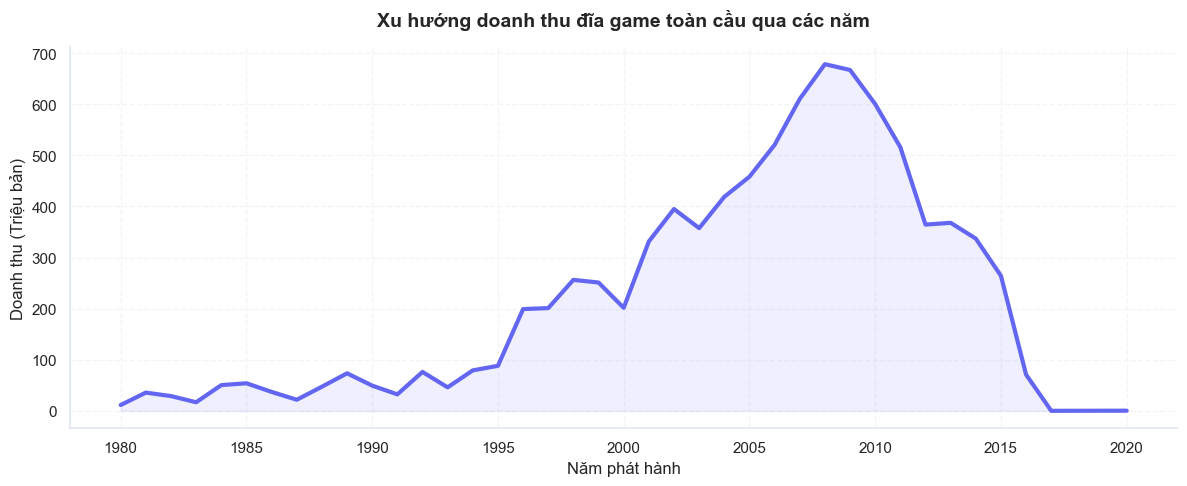

In [4]:
sales_by_year = df.groupby('Year')['Global_Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
ax = sns.lineplot(data=sales_by_year, x='Year', y='Global_Sales', color=COLOR_MAIN, linewidth=3)
plt.fill_between(sales_by_year['Year'], sales_by_year['Global_Sales'], color=COLOR_MAIN, alpha=0.1)
plt.title('Xu hướng doanh thu đĩa game toàn cầu qua các năm')
plt.xlabel('Năm phát hành')
plt.ylabel('Doanh thu (Triệu bản)')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


## 2. Tỉ trọng doanh thu theo từng khu vực
**Mô tả:** Biểu đồ tròn phong cách Donut hiện đại thể hiện mức độ đóng góp của từng thị trường.
- **Nhận xét:** **Bắc Mỹ (NA)** chiếm **48.6%** (Indigo) và **Châu Âu (EU)** chiếm **27.3%** (Coral Orange). Đây là 2 thị trường tiêu thụ đĩa game lớn nhất thế giới.

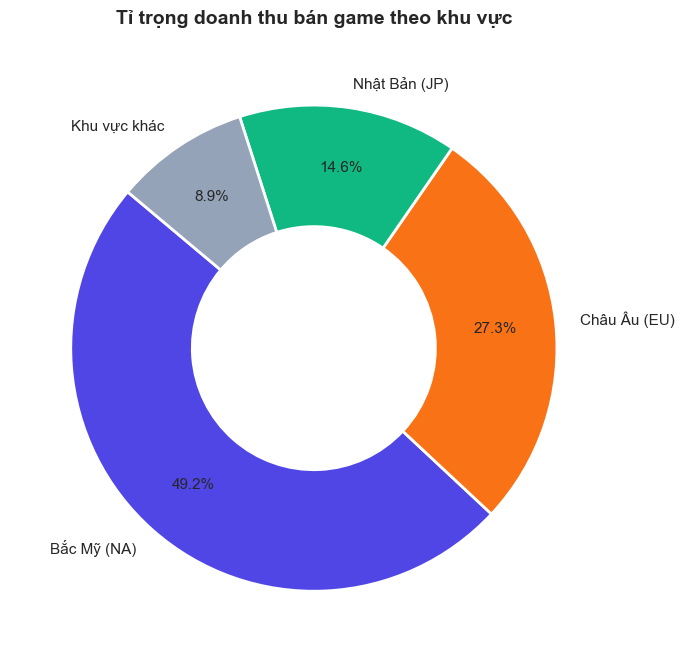

In [5]:
sales_by_region = [df['NA_Sales'].sum(), df['EU_Sales'].sum(), df['JP_Sales'].sum(), df['Other_Sales'].sum()]
labels = ['Bắc Mỹ (NA)', 'Châu Âu (EU)', 'Nhật Bản (JP)', 'Khu vực khác']

plt.figure(figsize=(7, 7))
# Donut chart hiện đại
plt.pie(sales_by_region, labels=labels, colors=PALETTE_REGIONS, autopct='%1.1f%%', startangle=140, 
        pctdistance=0.75, wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.5})
plt.title('Tỉ trọng doanh thu bán game theo khu vực')
plt.tight_layout()
plt.show()


## 3. Top 10 Thể loại game (Genre) bán chạy nhất (Tổng doanh thu)
**Mô tả:** Thống kê tổng doanh thu theo thể loại game.
- **Nhận xét:** **Action (Hành động)** và **Sports (Thể thao)** là hai thể loại áp đảo về tổng doanh số.

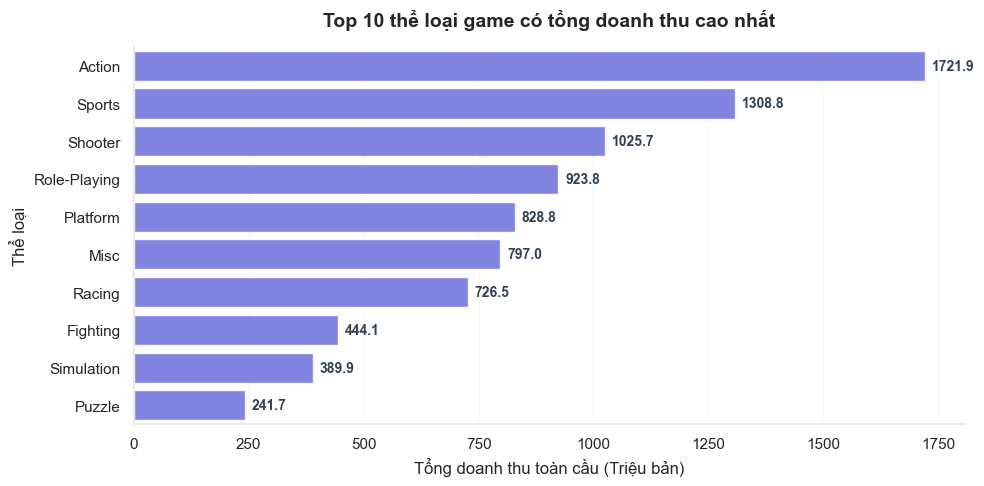

In [6]:
sales_by_genre = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=sales_by_genre, x='Global_Sales', y='Genre', color=COLOR_MAIN, alpha=0.9)
plt.title('Top 10 thể loại game có tổng doanh thu cao nhất')
plt.xlabel('Tổng doanh thu toàn cầu (Triệu bản)')
plt.ylabel('Thể loại')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}', (width + 15, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', color='#334155')

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


## 4. Top 10 Nhà phát hành (Publisher) có tổng doanh thu cao nhất
**Mô tả:** Xếp hạng các hãng phát hành game lớn nhất thế giới theo tổng doanh số.
- **Nhận xét:** **Nintendo** giữ vị trí số 1 tuyệt đối với hơn 1780 triệu bản.

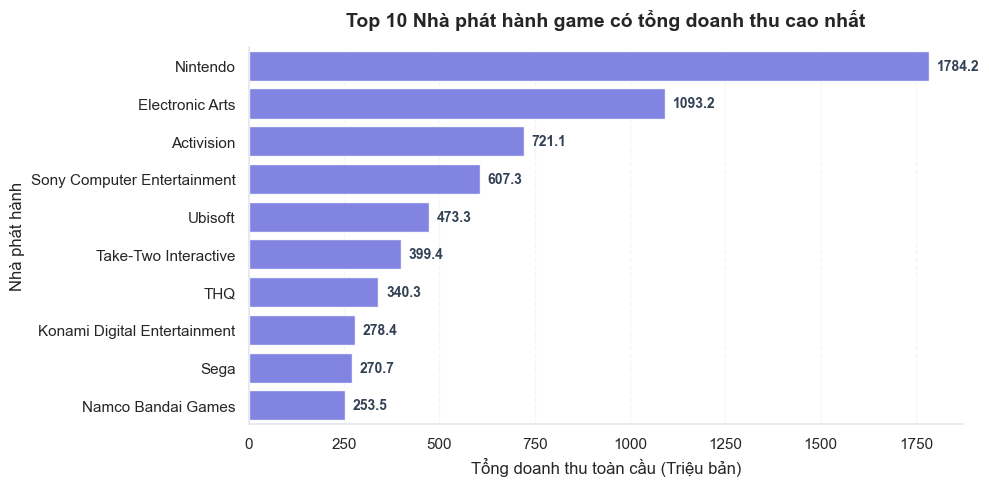

In [7]:
sales_by_publisher = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=sales_by_publisher, x='Global_Sales', y='Publisher', color=COLOR_MAIN, alpha=0.9)
plt.title('Top 10 Nhà phát hành game có tổng doanh thu cao nhất')
plt.xlabel('Tổng doanh thu toàn cầu (Triệu bản)')
plt.ylabel('Nhà phát hành')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}', (width + 20, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', color='#334155')

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


## 5. Top 10 Hệ máy (Platform) phổ biến nhất
**Mô tả:** Thống kê doanh thu đĩa game theo từng hệ máy.
- **Nhận xét:** **PS2** và **X360** là hai hệ máy dẫn đầu về lượng tiêu thụ đĩa game.

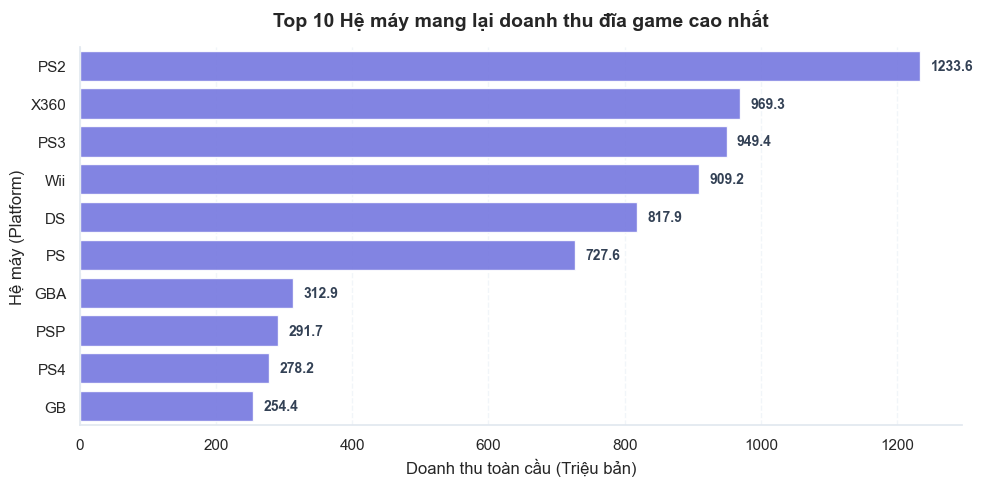

In [8]:
sales_by_platform = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=sales_by_platform, x='Global_Sales', y='Platform', color=COLOR_MAIN, alpha=0.9)
plt.title('Top 10 Hệ máy mang lại doanh thu đĩa game cao nhất')
plt.xlabel('Doanh thu toàn cầu (Triệu bản)')
plt.ylabel('Hệ máy (Platform)')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}', (width + 15, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', color='#334155')

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


## 6. So sánh trực tiếp doanh số Bắc Mỹ (NA) vs Châu Âu (EU) theo Thể loại
**Mô tả:** So sánh thị hiếu giữa Bắc Mỹ (Indigo) và Châu Âu (Modern Orange).
- **Nhận xét:** Bắc Mỹ áp đảo Châu Âu ở tất cả các thể loại, nhưng cơ cấu tỷ lệ chênh lệch rất tương đồng.

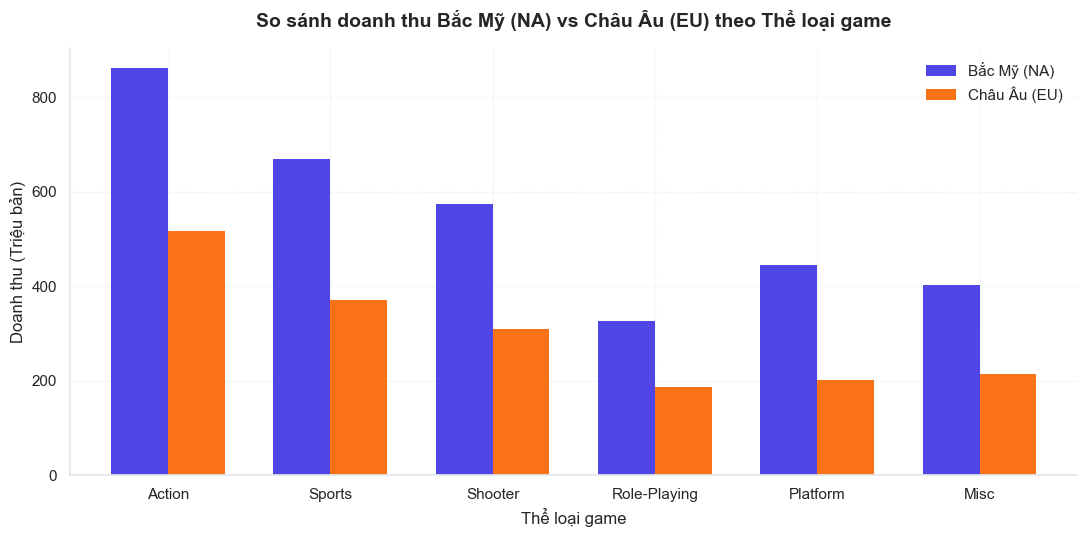

In [9]:
top_genres = sales_by_genre.head(6)['Genre'].tolist()
df_top_g = df[df['Genre'].isin(top_genres)]

na_vs_eu_genre = df_top_g.groupby('Genre')[['NA_Sales', 'EU_Sales']].sum().loc[top_genres]

ax = na_vs_eu_genre.plot(kind='bar', figsize=(11, 5.5), width=0.7, color=[COLOR_NA, COLOR_EU], edgecolor='none')
plt.title('So sánh doanh thu Bắc Mỹ (NA) vs Châu Âu (EU) theo Thể loại game')
plt.xlabel('Thể loại game')
plt.ylabel('Doanh thu (Triệu bản)')
plt.legend(['Bắc Mỹ (NA)', 'Châu Âu (EU)'], frameon=True, facecolor='white', edgecolor='none')
plt.xticks(rotation=0)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


## 7. So sánh trực tiếp doanh số Bắc Mỹ (NA) vs Châu Âu (EU) ở Top 10 Game
**Mô tả:** So sánh doanh số bán đĩa ở 2 thị trường lớn của 10 tựa game lớn nhất.
- **Nhận xét:** Riêng *Mario Kart Wii*, doanh thu ở Châu Âu tiệm cận rất sát với Bắc Mỹ.

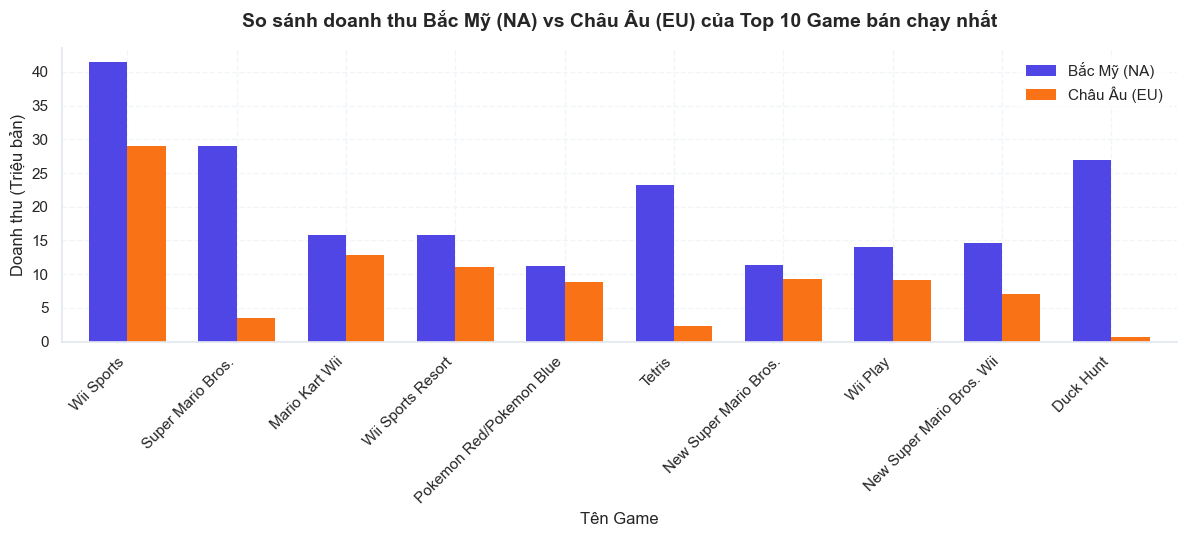

In [10]:
top_10_games = df.head(10)

ax = top_10_games.set_index('Name')[['NA_Sales', 'EU_Sales']].plot(
    kind='bar', figsize=(12, 5.5), width=0.7, color=[COLOR_NA, COLOR_EU], edgecolor='none'
)

plt.title('So sánh doanh thu Bắc Mỹ (NA) vs Châu Âu (EU) của Top 10 Game bán chạy nhất')
plt.xlabel('Tên Game')
plt.ylabel('Doanh thu (Triệu bản)')
plt.legend(['Bắc Mỹ (NA)', 'Châu Âu (EU)'], frameon=True, facecolor='white', edgecolor='none')
plt.xticks(rotation=45, ha='right')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


## 8. Cấu trúc doanh thu đầy đủ theo 4 khu vực của Top 10 Game
**Mô tả:** Xem xét tỷ lệ đóng góp của cả 4 khu vực vào doanh số của 10 siêu phẩm.
- **Nhận xét:** *Pokemon Red/Blue* có đóng góp từ Nhật Bản (Emerald Green) cực kỳ ấn tượng.

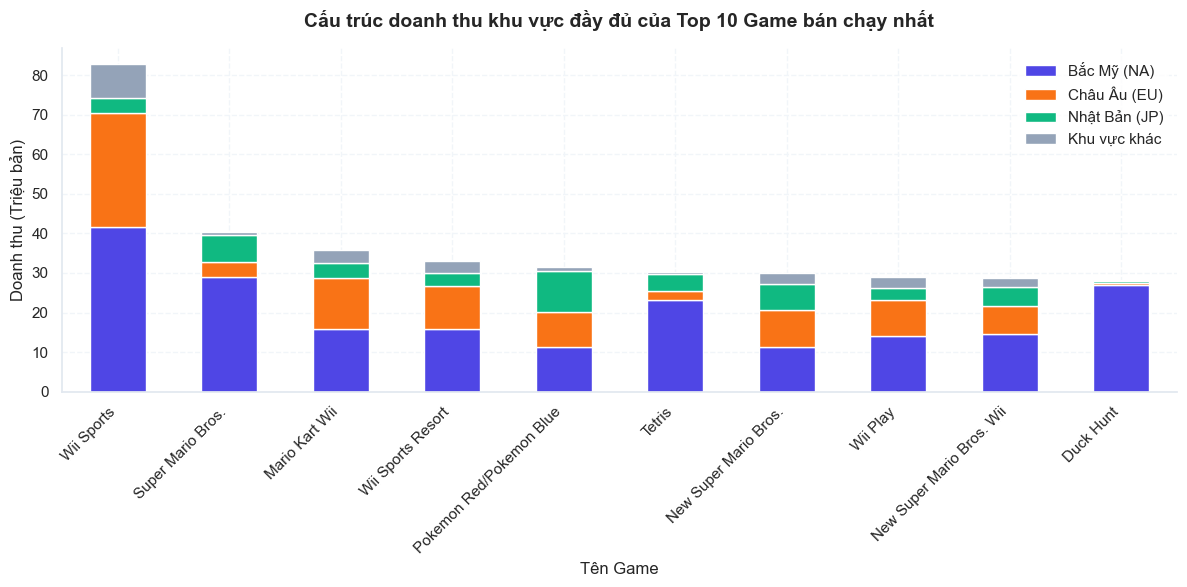

In [11]:
ax = top_10_games.set_index('Name')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].plot(
    kind='bar', stacked=True, figsize=(12, 6), color=PALETTE_REGIONS, edgecolor='white', linewidth=1
)

plt.title('Cấu trúc doanh thu khu vực đầy đủ của Top 10 Game bán chạy nhất')
plt.xlabel('Tên Game')
plt.ylabel('Doanh thu (Triệu bản)')
plt.legend(['Bắc Mỹ (NA)', 'Châu Âu (EU)', 'Nhật Bản (JP)', 'Khu vực khác'], frameon=True, facecolor='white', edgecolor='none')
plt.xticks(rotation=45, ha='right')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


## 9. Phân tích Chuyên sâu 1: Top 10 Nhà phát hành có Hiệu suất Trung bình / Game cao nhất
*(Điều kiện lọc: Đã phát hành tối thiểu 20 tựa game)*

**Mô tả:** Đo lường **Doanh thu Trung bình trên mỗi đầu game** phát hành.
- **Nhận xét bất ngờ:** **Take-Two Interactive** (hãng mẹ của Rockstar Games với dòng *GTA*) vọt lên vị trí số 2 với **1.56 triệu bản / game**, chứng minh chiến lược "ít nhưng chất" cực kỳ hiệu quả.

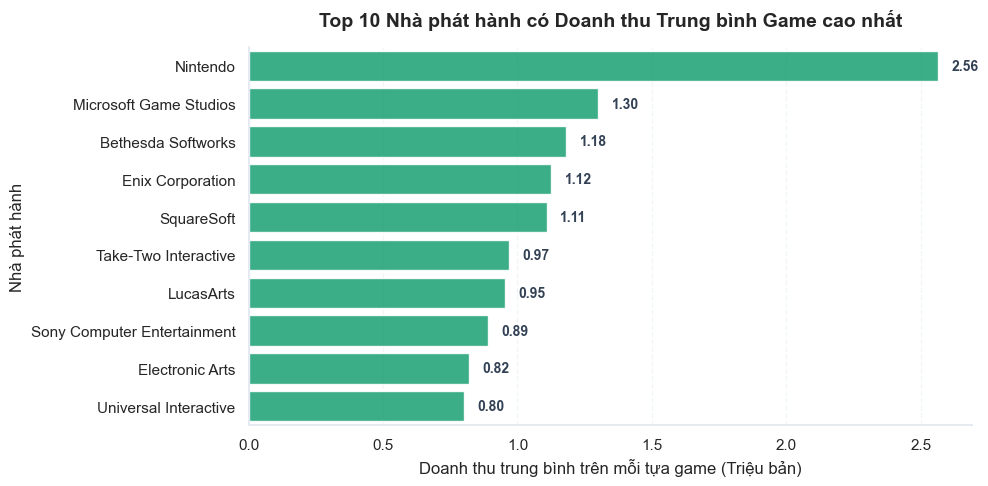

In [12]:
pub_stats = df.groupby('Publisher').agg(
    Total_Games=('Name', 'count'),
    Avg_Sales=('Global_Sales', 'mean'),
    Total_Sales=('Global_Sales', 'sum')
).reset_index()

top_avg_pub = pub_stats[pub_stats['Total_Games'] >= 20].sort_values('Avg_Sales', ascending=False).head(10)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top_avg_pub, x='Avg_Sales', y='Publisher', color=COLOR_JP, alpha=0.9)
plt.title('Top 10 Nhà phát hành có Doanh thu Trung bình Game cao nhất')
plt.xlabel('Doanh thu trung bình trên mỗi tựa game (Triệu bản)')
plt.ylabel('Nhà phát hành')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.2f}', (width + 0.05, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', color='#334155')

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


## 10. Phân tích Chuyên sâu 2: Sự chuyển dịch Thể loại game qua các Thập niên (80s, 90s, 2000s, 2010s)
**Mô tả:** Biểu đồ thể hiện sự thay đổi thị hiếu chơi game của thế giới qua 4 thập kỷ.
- **Nhận xét:** Sự bùng nổ của **Action** và **Shooter** ở thập niên 2000s và 2010s.

<Figure size 1200x600 with 0 Axes>

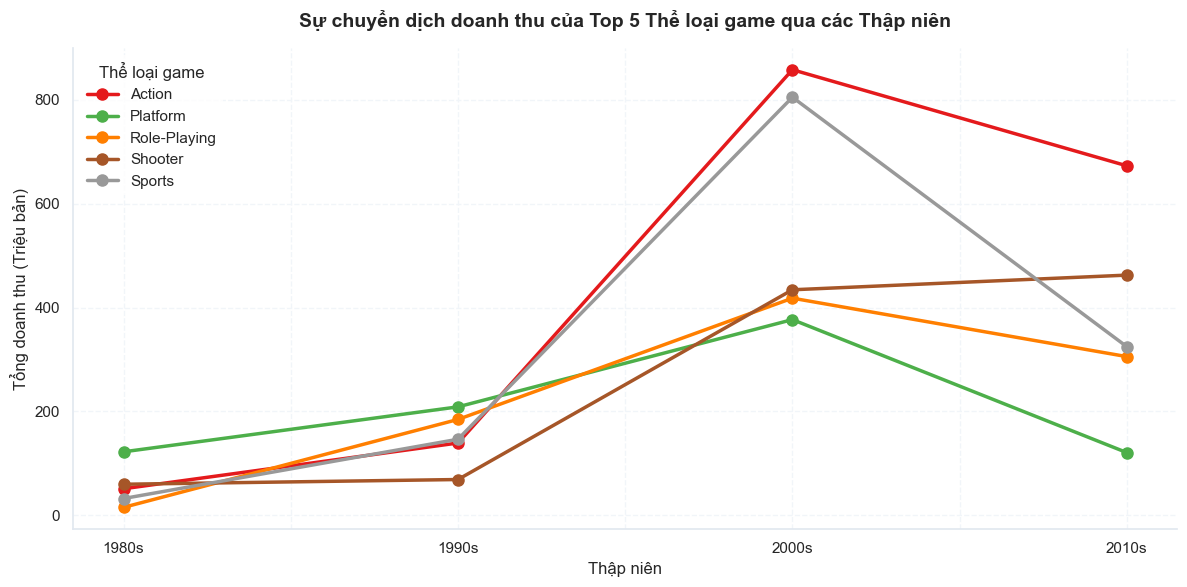

In [13]:
def get_decade(year):
    if year < 1990: return '1980s'
    elif year < 2000: return '1990s'
    elif year < 2010: return '2000s'
    else: return '2010s'

df['Decade'] = df['Year'].apply(get_decade)

top5_g = sales_by_genre.head(5)['Genre'].tolist()
decade_genre = df[df['Genre'].isin(top5_g)].groupby(['Decade', 'Genre'])['Global_Sales'].sum().unstack()

# Chuyển sang Biểu đồ Đường (Line Chart) với marker các điểm thập niên
plt.figure(figsize=(12, 6))
ax = decade_genre.plot(kind='line', marker='o', linewidth=2.5, markersize=8, figsize=(12, 6), colormap='Set1')
plt.title('Sự chuyển dịch doanh thu của Top 5 Thể loại game qua các Thập niên')
plt.xlabel('Thập niên')
plt.ylabel('Tổng doanh thu (Triệu bản)')
plt.legend(title='Thể loại game', frameon=True, facecolor='white', edgecolor='none')
plt.xticks(rotation=0)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

## 11. Phân tích Chuyên sâu 3: Cơ cấu Thể loại game trên Top 5 Hệ máy bán chạy nhất
**Mô tả:** Biểu đồ tỷ lệ 100% (Stacked 100%) giải thích yếu tố giúp từng hệ máy thành công.
- **Nhận xét:** Wii/DS mạnh về Misc/Sports/RPG; PS2/PS3/X360 áp đảo về Action/Shooter.

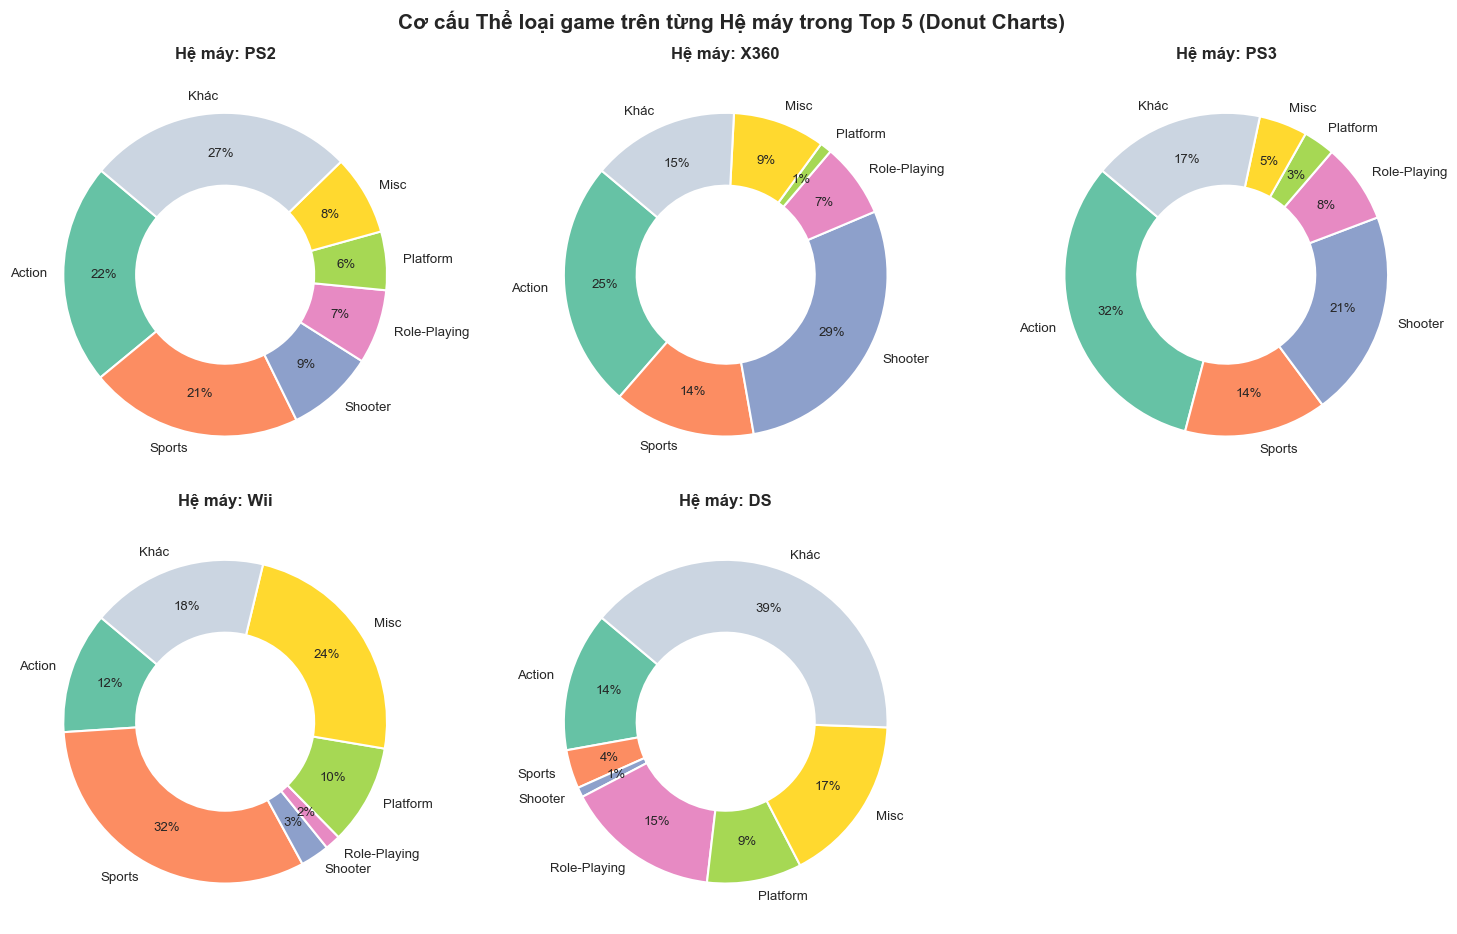

In [14]:
top5_platforms = sales_by_platform.head(5)['Platform'].tolist()
top6_genres = sales_by_genre.head(6)['Genre'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
axes = axes.flatten()

# Bảng màu nhất quán cho các thể loại trên tất cả biểu đồ
palette_genres = sns.color_palette("Set2", len(top6_genres))
genre_colors = {g: palette_genres[i] for i, g in enumerate(top6_genres)}
genre_colors['Khác'] = '#cbd5e1'

for idx, platform in enumerate(top5_platforms):
    df_p = df[df['Platform'] == platform].copy()
    df_p['Genre_Group'] = df_p['Genre'].apply(lambda x: x if x in top6_genres else 'Khác')
    p_genre_sales = df_p.groupby('Genre_Group')['Global_Sales'].sum()
    
    ordered_labels = [g for g in top6_genres if g in p_genre_sales.index] + (['Khác'] if 'Khác' in p_genre_sales.index else [])
    p_values = [p_genre_sales[g] for g in ordered_labels]
    p_colors = [genre_colors[g] for g in ordered_labels]
    
    ax = axes[idx]
    ax.pie(p_values, labels=ordered_labels, colors=p_colors, autopct='%1.0f%%', startangle=140,
           pctdistance=0.75, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'width': 0.45},
           textprops={'fontsize': 9.5})
    ax.set_title(f'Hệ máy: {platform}', fontweight='bold', fontsize=12, pad=10)

# Tắt subplot thứ 6 dư thừa
axes[5].axis('off')

plt.suptitle('Cơ cấu Thể loại game trên từng Hệ máy trong Top 5 ', fontweight='bold', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()